# Somalia workflow: Step 4: Station selection

NGA step 4 adapted: rank candidates by best lag-adjusted Spearman rho and
keep the top set for the action-trigger grid search. Somalia departures:

1. **Benchmark = SWALIM** (step 3 settled this: median rho 0.65-0.86 vs
   SFED's 0.21-0.46 with spurious negatives).
2. **Per river x season** selections (Gu and Deyr are separate windows).
3. **Operational eligibility filter**: a selected series must have a usable
   forecast product. `google_grrr` (reforecast 2016-2023 + live Flood Hub)
   and `glofas_v4` (reforecast 2003-2023 + operational forecast) qualify.
   `glofas_v5` (no reforecast exists) and `geoglows` (forecast climatology
   incompatible with retrospective-fitted thresholds; no reforecast archive)
   are shown for reference but not selectable.
4. **One source per station**: consensus should be spatial, not the same
   water level seen through two models. Per station keep its best-rho
   eligible source.

**Output**: `som_selected_stations.parquet`: per (river, season): the
selected (station, source) set with best_rho/best_lag.

In [1]:
import sys

sys.path.insert(0, "..")

import os
import tempfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ocha_stratus as stratus
import geopandas as gpd, tempfile, os

from src.constants import (
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
def load(name):
    return stratus.load_parquet_from_blob(f"ds-aa-som-floods/processed/{name}.parquet", stage="dev")

corr = load("workflow/som_gauge_correlations")  # reanalysis correlations (nb06)

# Selection basis: REANALYSIS correlation, as in the Nigeria framework
# ("calibrated/backtested on reanalysis because the reforecast archive is
# short; reforecast used for operational activation"). The forecast-side
# correlations (nb06, som_gauge_correlations_forecast) serve as validation,
# mirroring Nigeria's reforecast check. Eligible sources per the v5
# directive: google_grrr + glofas_v5.
ELIGIBLE = ["google_grrr", "glofas_v5"]
TOP_N = 8          # per river x season (rivers have 8-10 stations)
MIN_RHO = 0.5      # floor: below this a station adds noise, not signal

cand = corr[(corr.benchmark == "swalim") & (corr.source.isin(ELIGIBLE))].copy()
# one source per station: keep the best-rho eligible source
cand = (cand.sort_values("best_rho", ascending=False)
        .drop_duplicates(subset=["river", "season", "station"]))
sel = (cand[cand.best_rho >= MIN_RHO]
       .sort_values(["river", "season", "best_rho"], ascending=[1, 1, 0])
       .groupby(["river", "season"]).head(TOP_N)
       .reset_index(drop=True))
print(sel.groupby(["river", "season"]).size().rename("n_selected").to_string())
sel


river     season
juba      deyr      8
          gu        8
shabelle  deyr      8
          gu        8


,station,source,river,season,benchmark,best_rho,best_lag,n_obs
0,dollow,glofas_v5,juba,deyr,swalim,0.868,5,2087
1,luuq,glofas_v5,juba,deyr,swalim,0.849,3,2087
2,bardheere,glofas_v5,juba,deyr,swalim,0.805,0,2087
3,saakow,glofas_v5,juba,deyr,swalim,0.799,-1,2088
4,bualle,glofas_v5,juba,deyr,swalim,0.790,-2,2088
5,kaitoi,glofas_v5,juba,deyr,swalim,0.781,-3,2088
6,juba_07,glofas_v5,juba,deyr,swalim,0.778,-5,2088
7,juba_05,glofas_v5,juba,deyr,swalim,0.778,-4,2088
8,bardheere,google_grrr,juba,gu,swalim,0.869,-1,1999
9,saakow,google_grrr,juba,gu,swalim,0.868,-1,1999


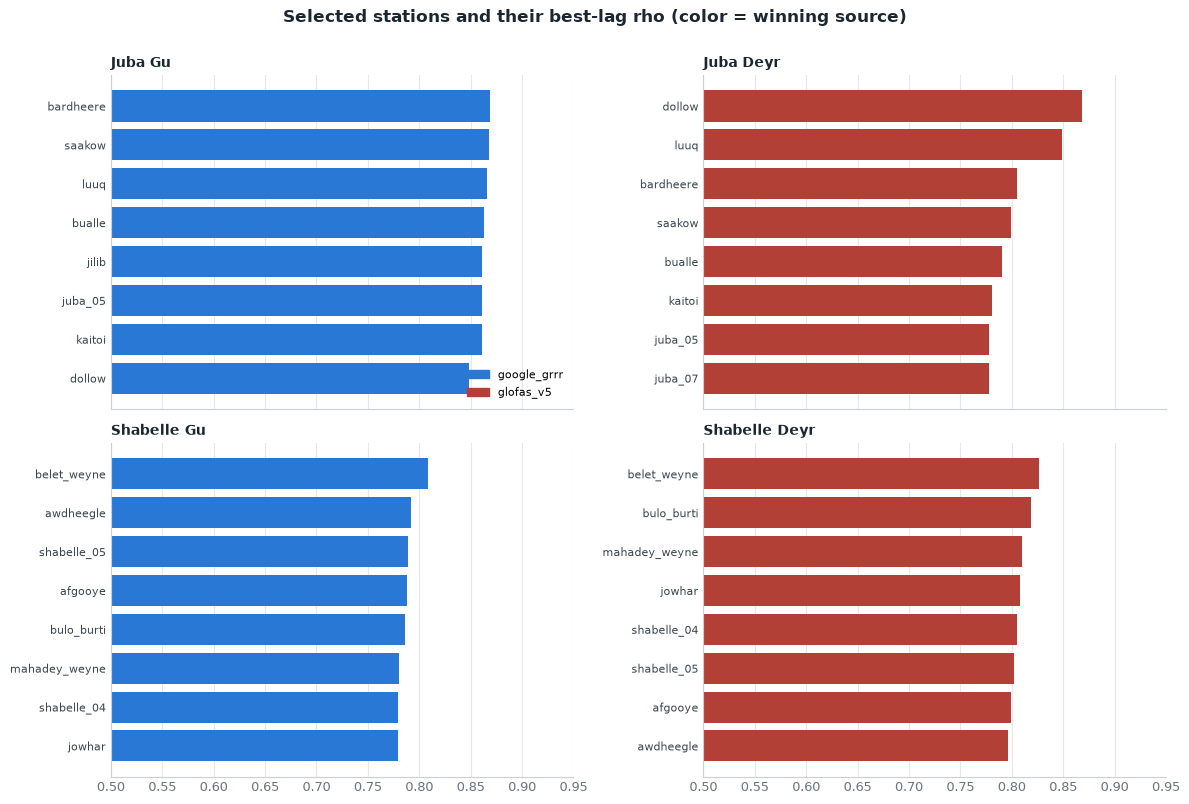

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
combos = [("juba", "gu"), ("juba", "deyr"), ("shabelle", "gu"), ("shabelle", "deyr")]
for ax, (river, season) in zip(axes.ravel(), combos):
    sub = sel[(sel.river == river) & (sel.season == season)].sort_values("best_rho")
    ax.barh(sub.station, sub.best_rho, color=[SOURCE_COLORS[s] for s in sub.source])
    ax.set_xlim(0.5, 0.95)
    ax.set_title(f"{river.capitalize()} {season.capitalize()}", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    style_ax(ax)
axes.ravel()[0].legend(
    handles=[
        mpatches.Patch(color=SOURCE_COLORS["google_grrr"], label="google_grrr"),
        mpatches.Patch(color=SOURCE_COLORS["glofas_v5"], label="glofas_v5"),
    ],
    fontsize=8,
    loc="lower right",
)
fig.suptitle("Selected stations and their best-lag rho (color = winning source)",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
plt.tight_layout()


## Reference: how the ineligible sources would have ranked

In [4]:
ref = corr[corr.benchmark == "swalim"].copy()
piv = ref.pivot_table(index=["river", "season"], columns="source",
                      values="best_rho", aggfunc="median").round(2)
piv


source           geoglows  glofas_v5  google_grrr
river    season                                  
juba     deyr        0.77       0.79         0.45
         gu          0.80       0.79         0.86
shabelle deyr        0.71       0.81         0.62
         gu          0.79       0.68         0.79

## Selected stations on the map, sized by rho

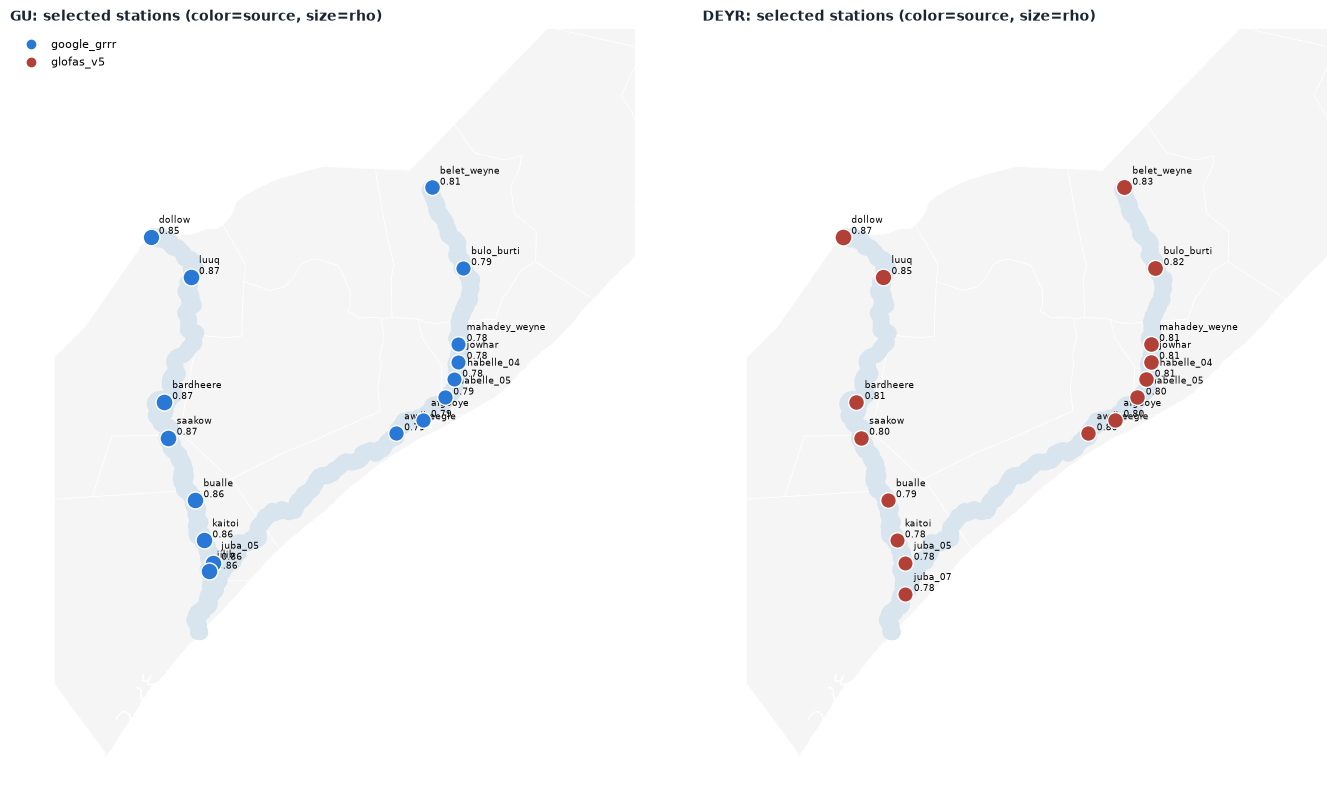

In [5]:
adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
SRC_COLORS = {"google_grrr": C_GOOGLE, "glofas_v5": C_GLOFAS5}
for ax, season in zip(axes, ["gu", "deyr"]):
    adm1.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.5)
    bufs.plot(ax=ax, color="#D8E4EE")
    sub = sel[sel.season == season]
    for _, r in sub.iterrows():
        st = STATIONS[r.station]
        ax.scatter(st.lon, st.lat, s=40 + 300 * (r.best_rho - 0.5),
                   color=SRC_COLORS[r.source], edgecolors="white", zorder=5)
        ax.annotate(f"{r.station}\n{r.best_rho:.2f}", (st.lon, st.lat),
                    textcoords="offset points", xytext=(6, 2), fontsize=6.5)
    ax.set_title(f"{season.upper()}: selected stations (color=source, size=rho)", loc="left", fontsize=10)
    ax.set_xlim(40.5, 47.5); ax.set_ylim(-2, 6.5)
handles = [plt.Line2D([], [], color=c, marker="o", ls="", label=s) for s, c in SRC_COLORS.items()]
axes[0].legend(handles=handles, fontsize=8, loc="upper left")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()


## Save

In [6]:
stratus.upload_parquet_to_blob(
    sel, "ds-aa-som-floods/processed/workflow/som_selected_stations.parquet", stage="dev")
print(f"uploaded som_selected_stations.parquet ({len(sel)} rows)")


uploaded som_selected_stations.parquet (32 rows)
